In [ ]:
import os
import requests
import zipfile
import io

PACKAGE_NAME = "Microsoft.AnalysisServices.AdomdClient"
VERSION = "19.113.2"
DLL_NAME = "Microsoft.AnalysisServices.AdomdClient.dll"

def download_and_extract_latest():
    script_dir = os.getcwd()
    print(f"📦 Downloading {PACKAGE_NAME} v{VERSION}...")
    

    url = f"https://www.nuget.org/api/v2/package/{PACKAGE_NAME}/{VERSION}"
    r = requests.get(url, allow_redirects=True)
    
    if r.status_code == 200:
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:

            dll_files = [n for n in z.namelist() if n.endswith(".dll") and "lib/" in n]
            
            for member in dll_files:
                filename = os.path.basename(member)
                target_path = os.path.join(script_dir, filename)
                
                with z.open(member) as source, open(target_path, "wb") as target:
                    target.write(source.read())
                print(f"   ✅ Extracted: {filename}")
                
        print(f"\n🚀 Done! {VERSION} files are now in: {script_dir}")
    else:
        print(f"❌ Failed to download. Status code: {r.status_code}")

if __name__ == "__main__":
    download_and_extract_latest()


In [ ]:

import os
import requests
import zipfile
import io


LIBRARIES = {
    "MSAL": {
        "package": "Microsoft.Identity.Client",
        "version": "4.65.0", # Exact version from your error
        "dll": "Microsoft.Identity.Client.dll"
    },
    "Identity_Abstractions": {
        "package": "Microsoft.IdentityModel.Abstractions",
        "version": "8.0.0", # Foundation for modern MSAL
        "dll": "Microsoft.IdentityModel.Abstractions.dll"
    }
}

def download_dependencies():
    script_dir = os.getcwd()
    
    for key, info in LIBRARIES.items():
        print(f"📦 Downloading {info['package']} v{info['version']}...")
        url = f"https://www.nuget.org/api/v2/package/{info['package']}/{info['version']}"
        r = requests.get(url, allow_redirects=True)
        
        if r.status_code == 200:
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                # We prioritize netstandard2.0 or net6.0 for Linux/CoreCLR compatibility
                dll_files = [n for n in z.namelist() if n.endswith(info['dll'])]
                
                # Filter for the best cross-platform version
                target_member = next((f for f in dll_files if "netstandard2.0" in f), 
                                     next((f for f in dll_files if "net6.0" in f), dll_files[0]))
                
                target_path = os.path.join(script_dir, info['dll'])
                with z.open(target_member) as source, open(target_path, "wb") as target:
                    target.write(source.read())
                print(f"   ✅ Extracted: {info['dll']}")
        else:
            print(f"❌ Failed to download {info['package']}. Status: {r.status_code}")

if __name__ == "__main__":
    download_dependencies()
    print("\n🚀 All identity foundations are now in your directory.")



In [ ]:
# Download the dotnet 10 binaries for the AdomdClient here https://dotnet.microsoft.com/en-us/download/dotnet
# extract the dotnet into %APPDATA%\Local\Microsoft\dotnet
# Add DOTNET_ROOT to your environment variables and point it to the dotnet folder you just extracted
# Then you should be able to run the code below to connect to your Power BI dataset using the AdomdClient.dll and the MSAL libraries for authentication.

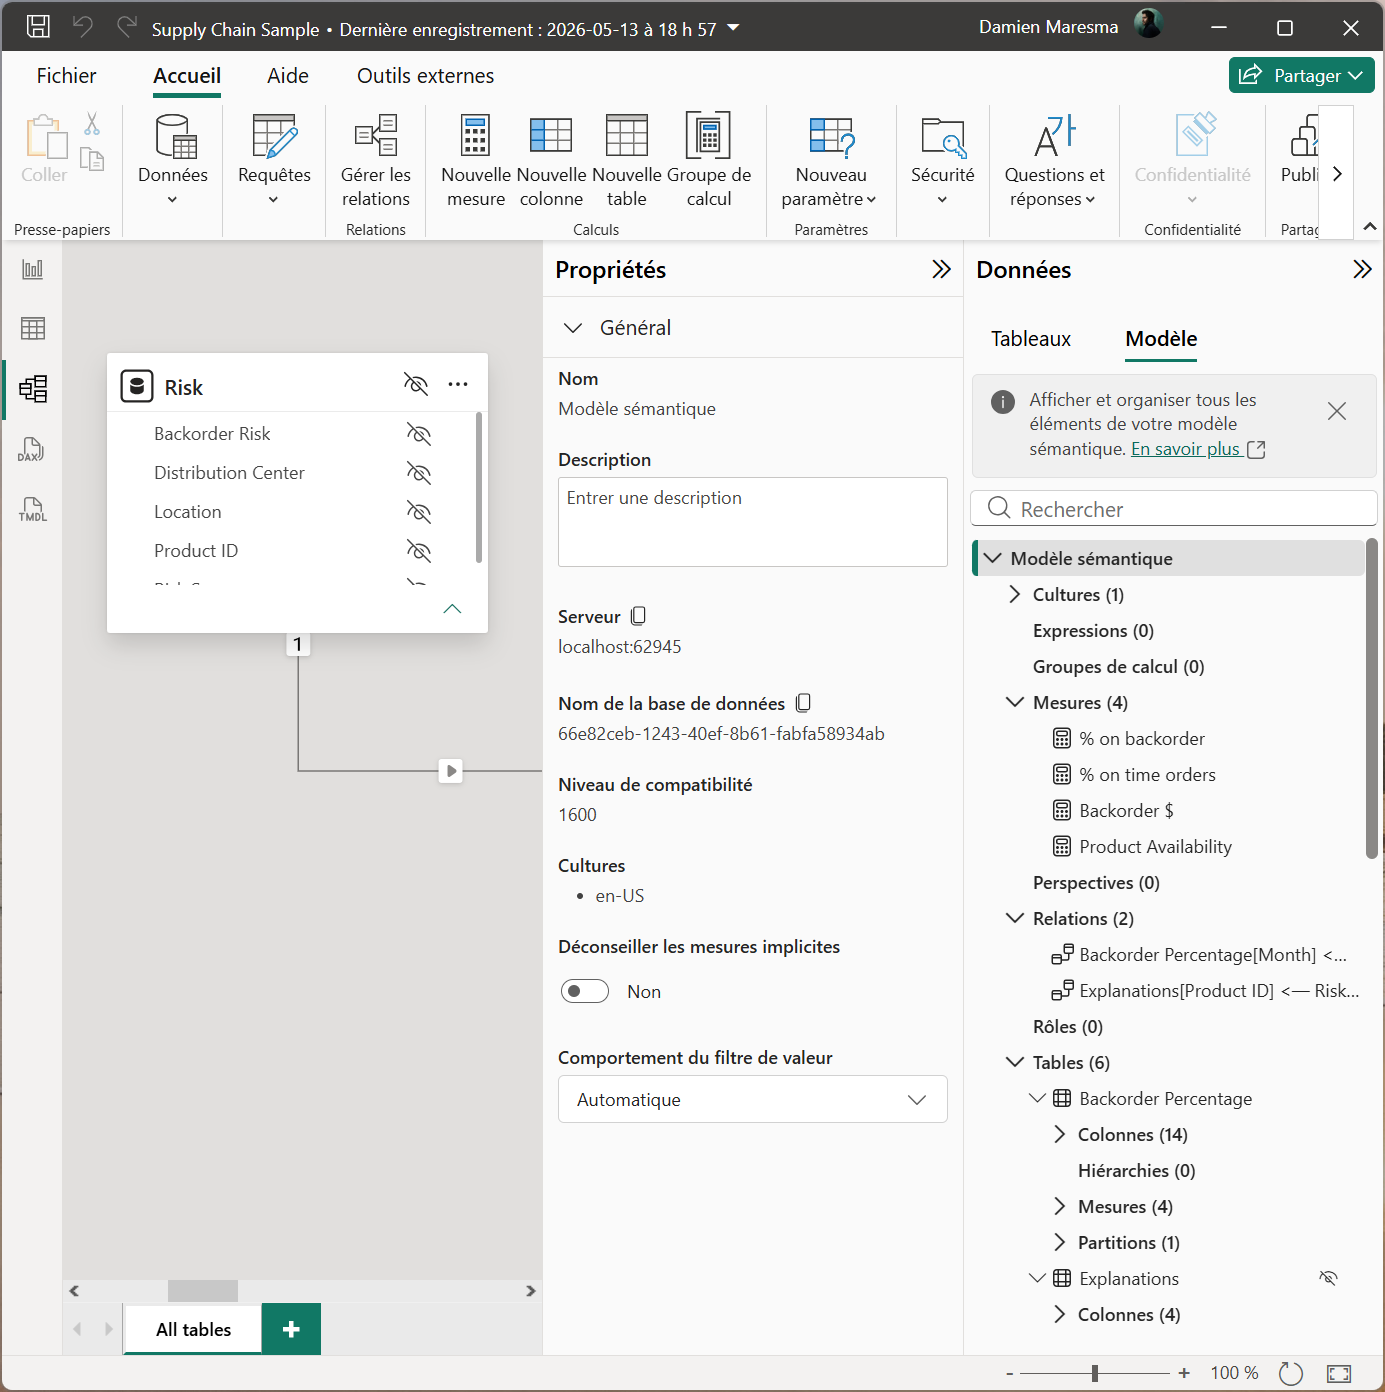

In [24]:
from sys import path


from pythonnet import load
load("coreclr")
import clr

from pyadomd import Pyadomd

conn = (
    f"Provider=MSOLAP;"
    f"Data Source=localhost:62945;"
    f"Initial Catalog=66e82ceb-1243-40ef-8b61-fabfa58934ab;"
)

query = """
Select * from $SYSTEM.TMSCHEMA_COLUMNS
-- Select * from $SYSTEM.DBSCHEMA_COLUMNS WHERE TABLE_SCHEMA = 'Model'
--select * from $SYSTEM.DBSCHEMA_PROVIDER_TYPES
"""


with Pyadomd(conn) as conn:
    with conn.cursor().execute(query) as cur:
        for record in cur.fetchall():
            print(record)

(14, 13, 'RowNumber-2662979B-1795-4F74-8F37-6A1BA8059B61', None, 6, 19, None, None, True, 1, True, True, False, 1, -1, False, False, 1, 58, 3, None, None, None, None, True, None, 15, datetime.datetime(2019, 3, 26, 0, 29, 3), datetime.datetime(2019, 3, 26, 0, 29, 3), datetime.datetime(1699, 12, 31, 0, 0), 2, False, 0, None, None, None, 0, None, None, None, None)
(16, 13, None, 'Date', 1, 9, 'PaddedDateTableDates', None, True, 1, False, False, True, 1, -1, False, False, 2, 62, 4, '[Date]', None, None, None, True, None, 46, datetime.datetime(2022, 9, 22, 23, 5, 40), datetime.datetime(2019, 3, 26, 0, 29, 3), datetime.datetime(1699, 12, 31, 0, 0), 2, False, 0, None, None, None, 0, None, None, '676c866c-449d-4a4d-93cb-181e610495a5', None)
(17, 13, 'Year', None, 1, 6, 'Years', None, True, 1, False, False, True, 1, -1, False, False, 2, 66, 2, None, None, 'YEAR([Date])', None, True, None, 47, datetime.datetime(2022, 9, 22, 23, 5, 40), datetime.datetime(2019, 3, 26, 0, 29, 3), datetime.datetime(

---
## Metadata Extraction & ODCS v3.1.0 Data Contract Generation

The cells below:
1. **Configure** the connection to the Power BI Desktop tabular instance.
2. **Extract** all tables, columns, measures, relationships and hierarchies via DMV queries.
3. **Generate** an [ODCS v3.1.0](https://github.com/bitol-io/open-data-contract-standard) data contract.
4. **Export** the contract to a `.odcs.yaml` file alongside this notebook.


In [12]:
# ── Parameters ────────────────────────────────────────────────────────────────
# Adjust port and catalog to match the running Power BI Desktop instance.
# Find the port: Task Manager → Details → AnalysisServices.exe → Resource Monitor TCP
PBIDESKTOP_PORT = "62945"
CATALOG_ID      = "66e82ceb-1243-40ef-8b61-fabfa58934ab"

CONNECTION_STRING = (
    f"Provider=MSOLAP;"
    f"Data Source=localhost:{PBIDESKTOP_PORT};"
    f"Initial Catalog={CATALOG_ID};"
)
print(f"🔗 Target: localhost:{PBIDESKTOP_PORT}  |  Catalog: {CATALOG_ID}")

🔗 Target: localhost:62945  |  Catalog: 66e82ceb-1243-40ef-8b61-fabfa58934ab


In [13]:
from pythonnet import load
load("coreclr")
import clr  # noqa: F401  (required by pythonnet before pyadomd)

from pyadomd import Pyadomd
import pandas as pd
import uuid
import yaml
from datetime import datetime, timezone


def run_dmv(query: str) -> pd.DataFrame:
    """Execute an Analysis Services DMV query and return a DataFrame."""
    with Pyadomd(CONNECTION_STRING) as conn:
        with conn.cursor().execute(query) as cur:
            cols = [desc[0] for desc in cur.description]
            rows = cur.fetchall()
    return pd.DataFrame(rows, columns=cols)


print("✅ Imports ready — pyadomd + pandas + pyyaml")

✅ Imports ready — pyadomd + pandas + pyyaml


In [33]:
# ── Extraction Functions ──────────────────────────────────────────────────────

def extract_model_info() -> pd.DataFrame:
    """Return catalog-level info (name, description, compatibility level)."""
    return run_dmv("SELECT * FROM $SYSTEM.DBSCHEMA_CATALOGS")


def extract_tables() -> pd.DataFrame:
    """Return all non-private tables from the tabular model."""
    df = run_dmv("SELECT * FROM $SYSTEM.TMSCHEMA_TABLES")
    if "IsPrivate" in df.columns:
        df = df[~df["IsPrivate"].astype(bool)]
    keep = [c for c in ["ID", "Name", "Description", "IsHidden", "DataCategory"]
            if c in df.columns]
    return df[keep].reset_index(drop=True)


def extract_columns() -> pd.DataFrame:
    """Return all data/calculated columns, excluding RowNumber system columns.

    ColumnType codes: 1=data, 2=calculated, 3=rowNumber, 4=calculatedTableColumn
    DataType codes  : 2=string, 6=int64, 8=double, 9=datetime,
                      10=decimal, 11=boolean, 17=binary, 19=variant
    """
    df = run_dmv("SELECT * FROM $SYSTEM.TMSCHEMA_COLUMNS")
    if "ColumnType" in df.columns:
        df = df[df["ColumnType"] != 3]   # drop rowNumber columns
    keep = [c for c in ["ID", "TableID", "ExplicitName", "DataType",
                        "IsHidden", "Description", "ColumnType",
                        "Expression", "FormatString", "Type"]
            if c in df.columns]
    return df[keep].reset_index(drop=True)


def extract_measures() -> pd.DataFrame:
    """Return all measures with their DAX expressions."""
    df = run_dmv("SELECT * FROM $SYSTEM.TMSCHEMA_MEASURES")
    keep = [c for c in ["ID", "TableID", "Name", "Description",
                        "Expression", "FormatString", "IsHidden"]
            if c in df.columns]
    return df[keep].reset_index(drop=True)


def extract_relationships() -> pd.DataFrame:
    """Return all relationships between tables."""
    df = run_dmv("SELECT * FROM $SYSTEM.TMSCHEMA_RELATIONSHIPS")
    keep = [c for c in ["ID", "FromTableID", "FromColumnID", "ToTableID",
                        "ToColumnID", "CrossFilteringBehavior",
                        "IsActive", "Cardinality"]
            if c in df.columns]
    return df[keep].reset_index(drop=True)


def extract_hierarchies() -> pd.DataFrame:
    """Return all user-defined hierarchies with their levels."""
    df = run_dmv("SELECT * FROM $SYSTEM.TMSCHEMA_HIERARCHIES")
    keep = [c for c in ["ID", "TableID", "Name", "Description", "IsHidden"]
            if c in df.columns]
    return df[keep].reset_index(drop=True)


# ── Run all extractions ───────────────────────────────────────────────────────
print("🔍 Extracting metadata from the Tabular Semantic Model...\n")

model_info_df    = extract_model_info()
tables_df        = extract_tables()
columns_df       = extract_columns()
measures_df      = extract_measures()
relationships_df = extract_relationships()
hierarchies_df   = extract_hierarchies()

catalog_name = (
    model_info_df["CATALOG_NAME"].iloc[0]
    if not model_info_df.empty and "CATALOG_NAME" in model_info_df.columns
    else CATALOG_ID
)
print(f"  📁 Catalog       : {catalog_name}")
print(f"  📊 Tables        : {len(tables_df)}")
print(f"  🔵 Columns       : {len(columns_df)}")
print(f"  📐 Measures      : {len(measures_df)}")
print(f"  🔗 Relationships : {len(relationships_df)}")
print(f"  🏔  Hierarchies   : {len(hierarchies_df)}")

🔍 Extracting metadata from the Tabular Semantic Model...

  📁 Catalog       : 66e82ceb-1243-40ef-8b61-fabfa58934ab
  📊 Tables        : 6
  🔵 Columns       : 54
  📐 Measures      : 4
  🔗 Relationships : 2
  🏔  Hierarchies   : 1


In [34]:
# ── Preview Extracted Metadata ────────────────────────────────────────────────
print("=== Tables ===")
display(tables_df)

print("\n=== Columns (first 30) ===")
display(columns_df.head(30))

print("\n=== Measures ===")
display(measures_df)

print("\n=== Relationships ===")
display(relationships_df)

print("\n=== Hierarchies ===")
display(hierarchies_df)

=== Tables ===


,ID,Name,Description,IsHidden,DataCategory
0,276,Supply Analytics,None,False,None
1,932,Risk,None,True,None
2,992,Explanations,None,True,None
3,2342,Logo,None,True,None
4,8304,Month,None,True,None
5,13029,Backorder Percentage,None,False,None



=== Columns (first 30) ===


,ID,TableID,ExplicitName,IsHidden,Description,Expression,FormatString,Type
0,14,13,RowNumber-2662979B-1795-4F74-8F37-6A1BA8059B61,True,None,None,None,3
1,16,13,None,True,None,None,None,4
2,17,13,Year,True,None,YEAR([Date]),None,2
3,18,13,MonthNo,True,None,MONTH([Date]),None,2
4,19,13,Month,True,None,"FORMAT([Date], ""MMMM"")",None,2
5,20,13,QuarterNo,True,None,INT(([MonthNo] + 2) / 3),None,2
6,21,13,Quarter,True,None,"""Qtr "" & [QuarterNo]",None,2
7,22,13,Day,True,None,DAY([Date]),None,2
8,277,276,RowNumber-2662979B-1795-4F74-8F37-6A1BA8059B61,True,None,None,None,3
9,280,276,Manufactured Goods %,True,None,None,0.00%;-0.00%;0.00%,1



=== Measures ===


,ID,TableID,Name,Description,Expression,FormatString,IsHidden
0,13669,13029,% on backorder,None,AVERAGE('Backorder Percentage'[Backorder %]),0.00%;-0.00%;0.00%,False
1,24942,13029,Backorder $,None,sum('Backorder Percentage'[Backorder %]) * 10000,"\$#,0.00;(\$#,0.00);\$#,0.00",False
2,24947,13029,Product Availability,None,AVERAGE('Backorder Percentage'[Backorder %]) * 15,0.00%;-0.00%;0.00%,False
3,24950,13029,% on time orders,None,AVERAGE('Backorder Percentage'[Backorder %]),None,False



=== Relationships ===


,ID,FromTableID,FromColumnID,ToTableID,ToColumnID,CrossFilteringBehavior,IsActive
0,1273,992,996,932,936,1,True
1,13652,13029,13034,8304,8309,1,True



=== Hierarchies ===


,ID,TableID,Name,Description,IsHidden
0,24,13,Date Hierarchy,None,False


In [ ]:
# ── ODCS v3.1.0 Type Mapping ─────────────────────────────────────────────────
from open_data_contract_standard.model import (
    CustomProperty,
    Relationship,
    SchemaProperty,
    SchemaObject,
)
from datacontract.imports.odcs_helper import create_property, create_schema_object

# Tabular DataType enum  ──►  ODCS logicalType / physicalType
# https://learn.microsoft.com/en-us/dotnet/api/system.data.oledb.oledbtype?view=netframework-4.8.1&viewFallbackFrom=net-10.0-pp
TABULAR_TYPE_MAP: dict[int, dict] = {
     
     2: {'logicalType': 'integer',   'physicalType': 'SHORT'},
     3: {'logicalType': 'integer',   'physicalType': 'LONG'},
     4: {'logicalType': 'number',    'physicalType': 'FLOAT'},
     5: {'logicalType': 'number',    'physicalType': 'DOUBLE'},
     6: {'logicalType': 'number',    'physicalType': 'CURRENCY'},
     7: {'logicalType': 'date',      'physicalType': 'DATE'},
     8: {'logicalType': 'string',    'physicalType': 'BSTR'},
    11: {'logicalType': 'boolean',   'physicalType': 'BOOL'},
    12: {'logicalType': 'string',    'physicalType': 'VARIANT'},
    14: {'logicalType': 'number',    'physicalType': 'DECIMAL'},
    18: {'logicalType': 'number',    'physicalType': 'USHORT'},
    19: {'logicalType': 'number',    'physicalType': 'ULONG'},
    20: {'logicalType': 'number',    'physicalType': 'BIGINT'},
    21: {'logicalType': 'number',    'physicalType': 'UBIGINT'},
    72: {'logicalType': 'string',    'physicalType': 'GUID'},
    128: {'logicalType': 'string',   'physicalType': 'BINARY'},
    129: {'logicalType': 'string',   'physicalType': 'CHAR'},
    130: {'logicalType': 'string',   'physicalType': 'WCHAR'},
    131: {'logicalType': 'number',   'physicalType': 'NUMERIC'},
    133: {'logicalType': 'date',     'physicalType': 'DATETIME'},
    134: {'logicalType': 'time',     'physicalType': 'TIME'},
    135: {'logicalType': 'timestamp','physicalType': 'TIMESTAMP'},
    200: {'logicalType': 'string',   'physicalType': 'VARCHAR'},
    201: {'logicalType': 'string',   'physicalType': 'LONGVARCHAR'},
    202: {'logicalType': 'string',   'physicalType': 'STRING'},
    203: {'logicalType': 'string',   'physicalType': 'STRING'},
    204: {'logicalType': 'string',   'physicalType': 'VARBINARY'},
    205: {'logicalType': 'string',   'physicalType': 'LONGVARBINARY'},
}

COLUMN_TYPE_LABELS: dict[int, str] = {
    1: 'data', 2: 'calculated', 4: 'calculatedTableColumn'
}
CARDINALITY_LABELS: dict[int, str] = {
    1: 'ManyToOne', 2: 'ManyToMany', 3: 'OneToOne'
}
CROSSFILTER_LABELS: dict[int, str] = {
    1: 'OneDirection', 2: 'BothDirections', 3: 'Automatic'
}


def _odcs_types(data_type_val) -> dict:
    """Map a Tabular DataType integer to ODCS logicalType / physicalType."""
    try:
        dt = int(data_type_val)
    except (TypeError, ValueError):
        dt = -1
    return TABULAR_TYPE_MAP.get(dt, {'logicalType': 'string', 'physicalType': 'unknown'})


def _clean(val) -> str:
    """Return a trimmed string, or empty string for None / NaN."""
    if val is None or (isinstance(val, float) and val != val):
        return ''
    return str(val).strip()


def _build_properties(
        table_id,
        columns_df,
        measures_df,
        rel_lookup: dict) -> list[SchemaProperty]:
    """Build the ODCS `properties` list for one table (columns + measures).

    rel_lookup maps  str(column_id)  →  list of Relationship objects.
    """
    props: list[SchemaProperty] = []

    # ── Regular & calculated columns ──────────────────────────────────────────
    if not columns_df.empty and 'TableID' in columns_df.columns:
        for _, col in columns_df[columns_df['TableID'] == table_id].iterrows():
            col_name = _clean(col.get('ExplicitName', ''))
            if not col_name:
                continue
            if col_name.startswith('RowNumber'):
                continue
            type_info    = _odcs_types(col.get('DataType'))
            col_type_int = (
                int(col.get('ColumnType', 1))
                if col.get('ColumnType') is not None else 1
            )
            col_id_str = _clean(col.get('ID', str(uuid.uuid4())[:8]))

            prop = create_property(
                name=col_name,
                logical_type=type_info['logicalType'],
                physical_type=type_info['physicalType'],
                description=_clean(col.get('Description', '')) or None,
                tags=[COLUMN_TYPE_LABELS.get(col_type_int, 'data')],
            )
            prop.id = f'col_{col_id_str}'
            prop.physicalName = col_name
            prop.customProperties = [
                CustomProperty(property='IsHidden', value=bool(col.get('IsHidden', False)))
            ]
            if fmt := _clean(col.get('FormatString', '')):
                prop.logicalType.format =fmt
                
            if col_type_int in (2, 4):          # calculated
                if expr := _clean(col.get('Expression', '')):
                    prop.transformLogic = expr
                    prop.transformDescription = 'DAX calculated column expression.'
            rels = rel_lookup.get(col_id_str, [])
            if rels:
                prop.relationships = rels
            props.append(prop)

    # ── Measures ──────────────────────────────────────────────────────────────
    if not measures_df.empty and 'TableID' in measures_df.columns:
        for _, meas in measures_df[measures_df['TableID'] == table_id].iterrows():
            meas_name = _clean(meas.get('Name', ''))
            if not meas_name:
                continue

            prop = create_property(
                name=meas_name,
                logical_type='number',
                physical_type='measure',
                description=_clean(meas.get('Description', '')) or None,
                tags=['measure'],
            )
            prop.id = f"meas_{_clean(meas.get('ID', str(uuid.uuid4())[:8]))}"
            prop.physicalName = meas_name
            prop.customProperties = [
                CustomProperty(property='IsHidden', value=bool(meas.get('IsHidden', False)))
            ]
            if expr := _clean(meas.get('Expression', '')):
                prop.transformLogic = expr
                prop.transformDescription = 'DAX measure expression.'
            if fmt := _clean(meas.get('FormatString', '')):
                prop.customProperties.append(
                    CustomProperty(property='formatString', value=fmt)
                )
            props.append(prop)

    return props


def build_odcs_schema(
        tables_df,
        columns_df,
        measures_df,
        rel_lookup: dict) -> list[SchemaObject]:
    """Build the ODCS `schema` array from extracted Tabular metadata.

    rel_lookup is produced by _build_rel_lookup() and carries pre-computed
    Relationship objects keyed by str(column_id).
    """
    schema: list[SchemaObject] = []
    for _, tbl in tables_df.iterrows():
        tbl_id   = tbl.get('ID', '')
        tbl_name = _clean(tbl.get('Name', ''))
        if not tbl_name:
            continue
        desc = _clean(tbl.get('Description', '')) or None
        dc   = _clean(tbl.get('DataCategory', ''))
        tags = [dc.lower()] if dc else []

        obj = create_schema_object(
            name=tbl_name,
            physical_type='table',
            description=desc,
            properties=_build_properties(tbl_id, columns_df, measures_df, rel_lookup),
            tags=tags,
        )
        obj.id = f"tbl_{_clean(str(tbl_id))}"
        obj.customProperties = [
            CustomProperty(property='IsHidden', value=bool(tbl.get('IsHidden', False)))
        ]
        schema.append(obj)
    return schema


print('✅ ODCS type mapping and schema builder functions defined')


✅ ODCS type mapping and schema builder functions defined


In [28]:
# ── ODCS v3.1.0 Contract Generator ──────────────────────────────────────────
import uuid as _uuid

from open_data_contract_standard.model import (
    Description,
    OpenDataContractStandard,
)
from datacontract.imports.odcs_helper import create_odcs, create_server


def _build_rel_lookup(
        tables_df,
        columns_df,
        relationships_df) -> dict:
    """
    Build a lookup  { str(from_col_id): [Relationship, ...] }
    where each Relationship carries ODCS property-level relationship data:

        to   : 'TargetTable.TargetColumn'  (ODCS shorthand notation)
        type : 'foreignKey'
        customProperties:
          - CustomProperty(property='isActive',               value=True)
          - CustomProperty(property='cardinality',            value='ManyToOne')
          - CustomProperty(property='crossFilteringBehavior', value='OneDirection')
    """
    if relationships_df.empty:
        return {}

    id_to_tbl = (
        dict(zip(tables_df['ID'].astype(str), tables_df['Name']))
        if not tables_df.empty else {}
    )
    id_to_col = (
        dict(zip(columns_df['ID'].astype(str), columns_df['ExplicitName']))
        if not columns_df.empty and 'ExplicitName' in columns_df.columns else {}
    )

    lookup: dict = {}
    for _, rel in relationships_df.iterrows():
        from_col_id = str(rel.get('FromColumnID', ''))
        to_tbl_name = id_to_tbl.get(str(rel.get('ToTableID', '')), '')
        to_col_name = id_to_col.get(str(rel.get('ToColumnID', '')), '')

        if not from_col_id or not to_tbl_name or not to_col_name:
            continue

        custom_props = [
            CustomProperty(property='isActive', value=bool(rel.get('IsActive', True))),
        ]
        if (card := rel.get('Cardinality')) is not None:
            custom_props.append(
                CustomProperty(
                    property='cardinality',
                    value=CARDINALITY_LABELS.get(int(card), str(card)),
                )
            )
        if (cf := rel.get('CrossFilteringBehavior')) is not None:
            custom_props.append(
                CustomProperty(
                    property='crossFilteringBehavior',
                    value=CROSSFILTER_LABELS.get(int(cf), str(cf)),
                )
            )

        rel_entry = Relationship(
            to=f'{to_tbl_name}.{to_col_name}',
            type='foreignKey',
            customProperties=custom_props,
        )
        lookup.setdefault(from_col_id, []).append(rel_entry)

    return lookup


def generate_odcs_contract(
    model_info_df,
    tables_df,
    columns_df,
    measures_df,
    relationships_df,
    contract_name:    str = None,
    contract_version: str = '1.0.0',
    status:           str = 'draft',
    domain:           str = '',
    owner:            str = '',
    description:      str = '',
) -> OpenDataContractStandard:
    """
    Generate an ODCS v3.1.0 data contract from extracted Power BI Tabular metadata.

    Relationships are embedded as ODCS `relationships` entries directly on the
    FROM column property (shorthand notation: TargetTable.TargetColumn).

    Returns
    -------
    OpenDataContractStandard  — call .to_yaml() to serialise.
    """
    catalog = CATALOG_ID
    if not model_info_df.empty and 'CATALOG_NAME' in model_info_df.columns:
        catalog = _clean(model_info_df['CATALOG_NAME'].iloc[0]) or catalog

    name       = contract_name or catalog
    rel_lookup = _build_rel_lookup(tables_df, columns_df, relationships_df)
    schema     = build_odcs_schema(tables_df, columns_df, measures_df, rel_lookup)

    odcs = create_odcs(
        id=str(_uuid.uuid4()),
        name=name,
        version=contract_version,
        status=status,
    )
    odcs.description = Description(
        purpose=(
            description
            or f'Semantic model exposed by Power BI Desktop (catalog: {catalog}).'
        )
    )
    odcs.servers = [
        create_server(
            name='Power BI Desktop',
            server_type='custom',
            host=f'localhost:{PBIDESKTOP_PORT}',
            database=catalog,
        )
    ]
    odcs.schema_ = schema

    if domain:
        odcs.domain = domain
    if owner:
        odcs.customProperties = [
            CustomProperty(property='owner', value=owner)
        ]

    return odcs


print('✅ generate_odcs_contract() defined')


✅ generate_odcs_contract() defined


In [29]:
# ── Generate the ODCS Contract ────────────────────────────────────────────────
odcs_contract = generate_odcs_contract(
    model_info_df    = model_info_df,
    tables_df        = tables_df,
    columns_df       = columns_df,
    measures_df      = measures_df,
    relationships_df = relationships_df,
    # ↓ Customize as needed
    contract_name    = None,       # defaults to catalog name
    contract_version = '1.0.0',
    status           = 'draft',
    domain           = '',
    owner            = '',
    description      = '',
)

# Print first 80 lines as a quick preview
yaml_str = odcs_contract.to_yaml()
lines = yaml_str.splitlines()
print('\n'.join(lines[:80]))
if len(lines) > 80:
    print(f'\n... ({len(lines) - 80} more lines — see export cell below)')


⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None', defaulting to string
⚠️ Warning: Invalid DataType value 'None

In [30]:
# ── Export ODCS Contract to YAML ─────────────────────────────────────────────
import os

safe_name   = odcs_contract.name.replace(' ', '_').replace('/', '_')
output_path = os.path.join(os.getcwd(), f'{safe_name}.odcs.yaml')

header = (
    f'# Generated by PythonOLAPClient  —  {datetime.now(timezone.utc).isoformat()}\n'
    f'# Standard : Open Data Contract Standard (ODCS) v3.1.0\n'
    f'# Source   : Power BI Desktop | port {PBIDESKTOP_PORT} | catalog {CATALOG_ID}\n'
    '\n'
)

with open(output_path, 'w', encoding='utf-8') as f:
    f.write(header)
    f.write(odcs_contract.to_yaml())

total_props = sum(len(t.properties or []) for t in (odcs_contract.schema_ or []))
print(f'✅ ODCS contract written to:\n   {output_path}')
print(f'   Tables     : {len(odcs_contract.schema_ or [])}')
print(f'   Properties : {total_props}  (columns + measures)')


✅ ODCS contract written to:
   c:\Users\dmaresma\Repos\PowerBI_PythonClient\66e82ceb-1243-40ef-8b61-fabfa58934ab.odcs.yaml
   Tables     : 6
   Properties : 44  (columns + measures)
